# The numbers

Every number in the README and on the project card comes from this notebook. It reads the warehouse
the pipeline builds (`docker compose up -d`, then `python pipeline.py` or the Airflow DAG), so start
those first. The rules themselves live once, in `sql/03_rules.sql`; this notebook only measures them.
Every client value (the connection, the rules, the check days, the colours) comes from
`config/client.yaml` through `load_config()`.

**What is measured, fixed before the first run:**

| Number | Definition |
|---|---|
| Sales rows | rows in the `sales` table: one per day, store and item |
| Stock-out | the first day a shelf closes empty (`on_hand = 0`, the day before it was not) |
| Warning days | days between the first reorder flag in the `rules.warning_window_days` days before a stock-out and the stock-out |
| Flagged in time | a stock-out with at least the item's `lead_days` + 1 days of warning. The flag is raised at closing, the email goes out the next morning, and the supplier delivers `lead_days` after the order, before that day's sales |
| Best sellers | the `report.best_sellers` items with the most units sold, all stores together |
| Slow stock | stock covering more than `rules.overstock_days` of sales (`status = 'Overstock'`), on the last day, with the month ends of the last year beside it |

One correction was made after the first demo run: "in time" first ignored the night between the flag
and the morning order. The README records the numbers before and after.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psycopg

sys.path.insert(0, str(Path.cwd().parent))
from config import load_config

cfg = load_config()
rules, report, w = cfg["rules"], cfg["report"], cfg["warehouse"]
CLIENT, CURRENCY = cfg["client"]["name"], cfg["client"]["currency"]
WINDOW = rules["warning_window_days"]
TEXT, MAIN, MUTED, DANGER = (report["colours"][k] for k in ("text", "data", "muted", "danger"))
MAIN = MAIN[0]
# Charts use the README's navy and teal look; the Power BI theme keeps client.yaml's colours.
TEXT, MAIN, MUTED = "#E2E8F0", "#2DD4BF", "#94A3B8"
plt.rcParams.update({"figure.facecolor": "#0F172A", "axes.facecolor": "#0F172A", "savefig.facecolor": "#0F172A",
                     "text.color": TEXT, "axes.labelcolor": TEXT, "axes.titlecolor": TEXT, "xtick.color": TEXT,
                     "ytick.color": TEXT, "legend.labelcolor": TEXT, "axes.edgecolor": "#334155", "grid.color": "#334155"})
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

conn = psycopg.connect(host=w["host"], port=w["port"], dbname=w["database"], user=w["user"], password=w["password"])

def query(sql, params=None):
    cur = conn.execute(sql, params)
    return pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])

## 1. The data: how many sales rows

In [2]:
sales_rows = query("SELECT count(*) AS n FROM sales").n[0]
print(f"{CLIENT}: {sales_rows:,} sales rows")
query("SELECT min(date) AS first_day, max(date) AS last_day, count(DISTINCT store) AS stores, count(DISTINCT item) AS items FROM sales")

Sample stores: 913,000 sales rows


,first_day,last_day,stores,items
0,2013-01-01,2017-12-31,10,50


## 2. The backtest: did the rule see each stock-out coming?

For every store and item, walk through the days in order. A stock-out starts on a day the shelf
closes empty after a day it did not. Then look back up to the warning window: the earliest day the
item was on the reorder list gives the warning days.

In [3]:
rule = query("""SELECT r.date, r.store, r.item, r.on_hand, r.order_qty > 0 AS flagged, r.status, r.stock_value,
                       r.days_of_cover, i.lead_days
                FROM stock_rule r JOIN item i USING (item) ORDER BY r.store, r.item, r.date""")
rule["date"] = pd.to_datetime(rule["date"])
rule[["stock_value", "days_of_cover"]] = rule[["stock_value", "days_of_cover"]].astype(float)
by_item = rule.groupby(["store", "item"])

empty = rule["on_hand"].eq(0)
rule["stockout"] = empty & ~by_item["on_hand"].shift(1).eq(0)

# warning days = the largest k (1..WINDOW) for which the item was flagged k days before
rule["warning_days"] = 0
for k in range(1, WINDOW + 1):
    flagged_k_days_before = by_item["flagged"].shift(k, fill_value=False).astype(bool)
    rule.loc[flagged_k_days_before, "warning_days"] = k

stockouts = rule[rule["stockout"]].copy()
stockouts["in_time"] = stockouts["warning_days"] >= stockouts["lead_days"] + 1
total, flagged = len(stockouts), int(stockouts["warning_days"].gt(0).sum())
in_time = int(stockouts["in_time"].sum())
print(f"{total:,} stock-outs: a flag came before {flagged:,} of them, "
      f"{in_time:,} ({in_time / max(total, 1):.0%}) early enough to order in time")
stockouts["warning_days"].value_counts().sort_index().rename("stock-outs").to_frame().T

4,052 stock-outs: a flag came before 4,052 of them, 1,643 (41%) early enough to order in time


warning_days,3,4,5,6
stock-outs,5,2404,1627,16


## 3. Best sellers: how much warning before they run out

In [4]:
units = query("SELECT item, sum(units_sold) AS units FROM sales GROUP BY item ORDER BY units DESC")
best_sellers = units.item.head(report["best_sellers"]).tolist()
best = stockouts[stockouts["item"].isin(best_sellers)]
best_warning = best["warning_days"].median()
print(f"Best sellers {best_sellers}: {len(best):,} of the {total:,} stock-outs, "
      f"median warning {best_warning:.0f} days, {best['in_time'].mean():.0%} flagged in time")

Best sellers [15, 28, 13, 18, 25, 38, 22, 45, 36, 8]: 3,919 of the 4,052 stock-outs, median warning 4 days, 41% flagged in time


## 4. Slow stock: how much stock value sits in slow stock

Measured on the last day, the morning the report and the email describe.

In [5]:
last_day = rule["date"].max()
today = rule[rule["date"] == last_day]
by_status = today.groupby("status")["stock_value"].sum().sort_values(ascending=False)
slow_share = by_status.get("Overstock", 0) / by_status.sum()
print(f"{last_day:%d %b %Y}: {slow_share:.0%} of stock value is in slow stock "
      f"(more than {rules['overstock_days']} days of cover)")
by_status.round(0).to_frame(f"stock value ({CURRENCY})")

31 Dec 2017: 37% of stock value is in slow stock (more than 30 days of cover)


,stock value (USD)
status,
OK,4864461.0
Overstock,2842562.0


The last day is one morning, so the same share at the end of every month of the last year in the
data (and on the last day) shows the range.

In [6]:
last_year = last_day.year
month_ends = rule[rule["date"].dt.year.eq(last_year) & (rule["date"].dt.is_month_end | rule["date"].eq(last_day))]
monthly_slow = month_ends.groupby("date")[["status", "stock_value"]].apply(
    lambda d: d.loc[d["status"].eq("Overstock"), "stock_value"].sum() / d["stock_value"].sum())
print(f"{last_year} month ends: {monthly_slow.min():.0%} to {monthly_slow.max():.0%}")
monthly_slow.map("{:.0%}".format).rename("slow stock share").to_frame().T

2017 month ends: 8% to 42%


date,2017-01-31,2017-02-28,2017-03-31,2017-04-30,2017-05-31,2017-06-30,2017-07-31,2017-08-31,2017-09-30,2017-10-31,2017-11-30,2017-12-31
slow stock share,42%,36%,29%,19%,18%,14%,8%,18%,18%,21%,20%,37%


## 5. The numbers for the card and the README

In [7]:
results = pd.Series({
    "Sales rows": f"{sales_rows:,}",
    "Stock-outs in the history": f"{total:,}",
    f"Stock-outs with a flag before them (1 to {WINDOW} days)": f"{flagged:,}",
    "Stock-outs flagged in time (lead time + 1 days)": f"{in_time:,} ({in_time / max(total, 1):.0%})",
    "Median warning before a best seller runs out": f"{best_warning:.0f} days",
    "Stock value in slow stock, last day": f"{slow_share:.0%}",
    f"Same, {last_year} month ends": f"{monthly_slow.min():.0%} to {monthly_slow.max():.0%}",
})
results.to_frame(CLIENT)

,Sample stores
Sales rows,"913,000"
Stock-outs in the history,"4,052"
Stock-outs with a flag before them (1 to 7 days),"4,052"
Stock-outs flagged in time (lead time + 1 days),"1,643 (41%)"
Median warning before a best seller runs out,4 days
"Stock value in slow stock, last day",37%
"Same, 2017 month ends",8% to 42%


## 6. Charts for the README

**The check shelf** (`report.check_shelf`): its stock against the reorder point. The dots are the
days it was on the reorder list; the shaded days its shelf was empty.

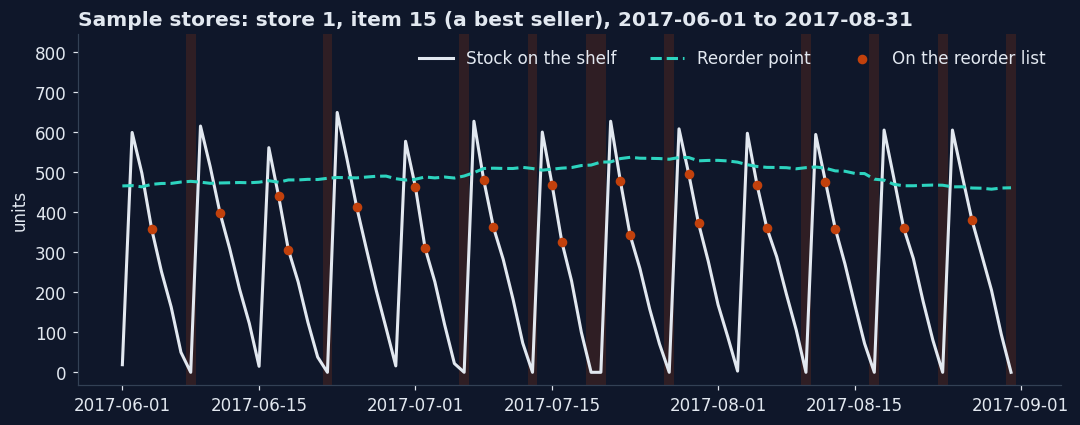

In [8]:
shelf = report["check_shelf"]
one = rule[(rule["store"] == shelf["store"]) & (rule["item"] == shelf["item"])
           & rule["date"].between(shelf["from"], shelf["to"])]
rop = query("""SELECT date, reorder_point FROM stock_rule WHERE store = %s AND item = %s
                AND date BETWEEN %s AND %s ORDER BY date""", [shelf["store"], shelf["item"], shelf["from"], shelf["to"]])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(one["date"], one["on_hand"], color=TEXT, lw=2, label="Stock on the shelf")
ax.plot(pd.to_datetime(rop["date"]), rop["reorder_point"].astype(float), color=MAIN, lw=2, ls="--", label="Reorder point")
ax.scatter(one.loc[one["flagged"], "date"], one.loc[one["flagged"], "on_hand"], color=DANGER, zorder=3, s=28, label="On the reorder list")
for d in one.loc[one["on_hand"].eq(0), "date"]:
    ax.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12), color=DANGER, alpha=0.18, lw=0)
best_note = " (a best seller)" if shelf["item"] in best_sellers else ""
ax.set_title(f"{CLIENT}: store {shelf['store']}, item {shelf['item']}{best_note}, {shelf['from']} to {shelf['to']}",
             loc="left", fontweight="bold")
ax.set_ylabel("units")
ax.set_ylim(top=max(one["on_hand"].max(), 1) * 1.3)
ax.legend(frameon=False, loc="upper right", ncol=3)
fig.tight_layout()
fig.savefig("../docs/chart-best-seller-summer.png")

**Stock-outs per month, and how many the rule flagged in time.**

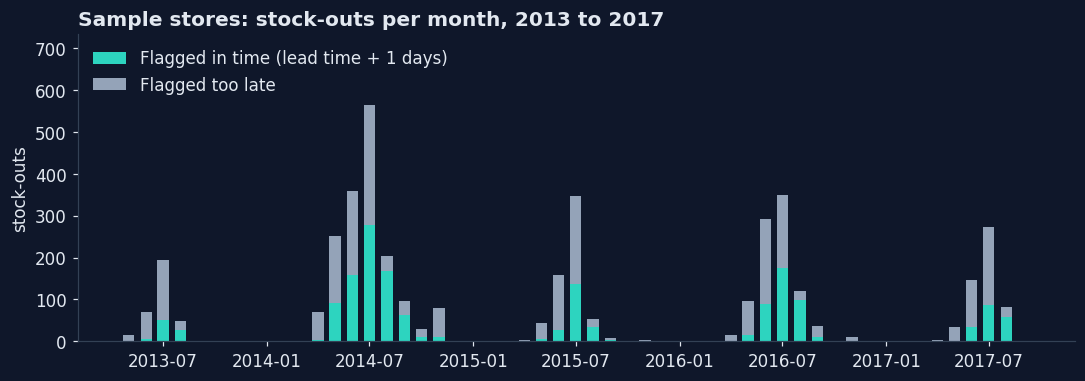

In [9]:
monthly = stockouts.groupby([stockouts["date"].dt.to_period("M"), "in_time"]).size().unstack(fill_value=0)
monthly = monthly.reindex(columns=[True, False], fill_value=0)
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar(monthly.index, monthly[True], width=20, color=MAIN, label="Flagged in time (lead time + 1 days)")
ax.bar(monthly.index, monthly[False], width=20, bottom=monthly[True], color=MUTED, label="Flagged too late")
ax.set_title(f"{CLIENT}: stock-outs per month, {rule['date'].min().year} to {last_year}", loc="left", fontweight="bold")
ax.set_ylabel("stock-outs")
ax.set_ylim(0, monthly.sum(axis=1).max() * 1.3)  # room for the legend above the tallest bar
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("../docs/chart-stockouts-per-month.png")

**Where the stock value sits on the last day.**

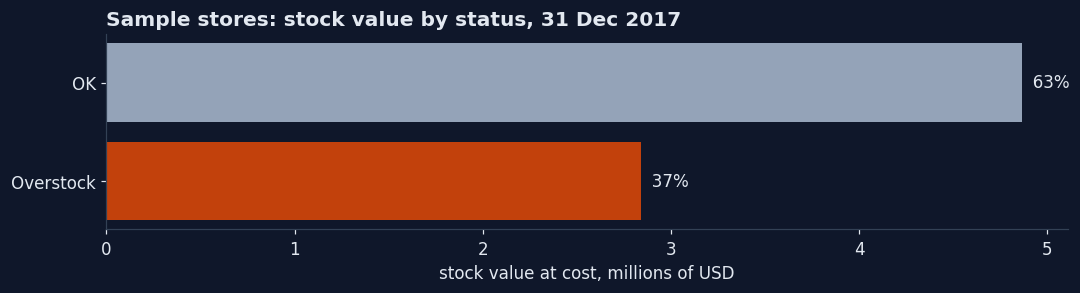

In [10]:
fig, ax = plt.subplots(figsize=(10, 2.8))
colors = [DANGER if s == "Overstock" else MUTED for s in by_status.index]
ax.barh(by_status.index[::-1], by_status.values[::-1], color=colors[::-1])
for y, v in enumerate(by_status.values[::-1]):
    ax.text(v, y, f"  {v / by_status.sum():.0%}", va="center")
ax.set_title(f"{CLIENT}: stock value by status, {last_day:%d %b %Y}", loc="left", fontweight="bold")
ax.set_xlabel(f"stock value at cost, millions of {CURRENCY}")
ax.xaxis.set_major_formatter(lambda x, _: f"{x / 1e6:g}")
fig.tight_layout()
fig.savefig("../docs/chart-stock-value-by-status.png")

## 7. What the Power BI report must show

`powerbi/06-checks.md` copies these numbers: build the report, pick the same day, and every card must
match. The days and the shelf are `report.check_days` and `report.check_shelf`.

In [11]:
full = query("SELECT date, store, item, units_sold, on_hand, order_qty, status, stock_value FROM stock_rule")
full["date"] = pd.to_datetime(full["date"])
full["stock_value"] = full["stock_value"].astype(float)

def day_cards(day):
    d = full[full["date"] == day]
    return pd.Series({
        "Items to Reorder": int((d["order_qty"] > 0).sum()),
        "Units to Order": int(d["order_qty"].sum()),
        "Out of Stock Items": int(d["status"].eq("Out of stock").sum()),
        "Stock Value": f"{d['stock_value'].sum():,.0f}",
        "Slow Stock Share": f"{d.loc[d['status'].eq('Overstock'), 'stock_value'].sum() / d['stock_value'].sum():.1%}",
        **{f"Store items: {s}": int(n) for s, n in d["status"].value_counts().items()},
    })

pd.concat({pd.Timestamp(day).strftime("%d %b %Y"): day_cards(day) for day in report["check_days"]}, axis=1).fillna("0")

,31 Dec 2017,16 Jul 2017
Items to Reorder,0,111
Units to Order,0,98020
Out of Stock Items,0,0
Stock Value,"7,707,022","5,826,826"
Slow Stock Share,36.9%,12.6%
Store items: OK,343,342
Store items: Overstock,157,47
Store items: Reorder,0,111


In [12]:
one_shelf = full[(full["store"] == shelf["store"]) & (full["item"] == shelf["item"])
                 & full["date"].between(shelf["from"], shelf["to"])]
label = f"Store {shelf['store']}, item {shelf['item']}, {shelf['from']} to {shelf['to']}"
pd.Series({
    "Rows (store, item, day)": f"{len(full):,}",
    "Units Sold, all days": f"{full['units_sold'].sum():,}",
    "Empty Shelf Days, all days": f"{full['on_hand'].eq(0).sum():,}",
    f"Empty Shelf Days, {last_year}": f"{full.loc[full['date'].dt.year.eq(last_year), 'on_hand'].eq(0).sum():,}",
    f"{label}: Empty Shelf Days": int(one_shelf["on_hand"].eq(0).sum()),
    f"{label}: Units Sold": f"{one_shelf['units_sold'].sum():,}",
}).to_frame("must show")

,must show
"Rows (store, item, day)","913,000"
"Units Sold, all days","47,514,528"
"Empty Shelf Days, all days","4,434"
"Empty Shelf Days, 2017",567
"Store 1, item 15, 2017-06-01 to 2017-08-31: Empty Shelf Days",11
"Store 1, item 15, 2017-06-01 to 2017-08-31: Units Sold","9,494"


## 8. Two numbers from the README's notes

Which weekday each stock-out starts on, and what the first run counted when lead time alone was taken
as enough warning (it ignored the night between the flag and the morning order).

In [13]:
weekday = stockouts["date"].dt.day_name().value_counts()
print(f"{weekday.iloc[0] / total:.0%} of the {total:,} stock-outs start on a {weekday.index[0]}: "
      + ", ".join(f"{day} {n:,}" for day, n in weekday.items()))
first_run = int(stockouts["warning_days"].ge(stockouts["lead_days"]).sum())
print(f"First run (lead time only): {first_run:,} of {total:,} counted as flagged in time")

91% of the 4,052 stock-outs start on a Thursday: Thursday 3,673, Wednesday 376, Tuesday 3
First run (lead time only): 4,047 of 4,052 counted as flagged in time
